# StarDist Fine-Tuning dari Pretrained `2D_versatile_he`

Notebook ini dibuat sebagai versi **fine-tuning** dari notebook training from scratch


In [ ]:
# INI ADALAH NOTEBOOK FINE TUNING STARDIST
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
!pip install -q imagecodecs
!pip install -q imagecodecs-numcodecs
!pip install -q stardist
!pip install -q matplotlib pandas

In [ ]:
from __future__ import print_function, unicode_literals, absolute_import, division

import os
import sys
import copy
import json
import random
from glob import glob
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams["image.interpolation"] = "None"
import matplotlib.pyplot as plt

from tqdm import tqdm
from tifffile import imread, imwrite

from csbdeep.utils import normalize
from stardist import fill_label_holes, random_label_cmap, calculate_extents, gputools_available
from stardist.matching import matching, matching_dataset
from stardist.models import StarDist2D

import tensorflow as tf
from IPython.display import display

In [5]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

lbl_cmap = random_label_cmap()

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU terdeteksi: {gpus}")
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth untuk GPU berhasil diaktifkan.")
    except Exception as e:
        print("Tidak bisa mengatur memory growth:", e)
else:
    print("GPU tidak terdeteksi. Training akan berjalan di CPU.")

print("TensorFlow version:", tf.__version__)

GPU terdeteksi: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth untuk GPU berhasil diaktifkan.
TensorFlow version: 2.16.1


In [6]:
TRAIN_SPLIT_DIR = '/data/work/DATASET_Training and Retraining/train'
VAL_SPLIT_DIR = '/data/work/DATASET_Training and Retraining/validation'
MODEL_BASEDIR = '/data/work/FineTuning/Models'

PRETRAINED_MODEL_NAME = '2D_versatile_he'
FINETUNE_MODEL_NAME = 'stardist_model_C_3000'

EPOCHS = 150
STEPS_PER_EPOCH = 100
LEARNING_RATE = 1e-4
BATCH_SIZE = 4
OPENCL_DATA_GENERATOR = False and gputools_available()  # ini bukan GPU TensorFlow

# Strategi untuk dataset campuran 256x256 dan 512x512
# 'auto_smallest'  -> train_patch_size otomatis diset <= gambar terkecil
# 'pad_to_pretrained' -> gambar kecil dipad ke patch pretrained (lebih banyak konteks, tetapi ada padding)
PATCH_SIZE_MODE = 'auto_smallest'
PATCH_SIZE_DIVISOR = 16
FORCE_PATCH_SIZE = None         # contoh: (256, 256). Jika None maka otomatis.
PAD_MODE = 'reflect'            # hanya dipakai jika PATCH_SIZE_MODE='pad_to_pretrained'

EXPORT_VAL_PREDICTIONS = True
PRED_EXPORT_DIR = os.path.join(MODEL_BASEDIR, FINETUNE_MODEL_NAME, 'val_predictions')

Path(MODEL_BASEDIR).mkdir(parents=True, exist_ok=True)
Path(PRED_EXPORT_DIR).mkdir(parents=True, exist_ok=True)

print("TRAIN_SPLIT_DIR:", TRAIN_SPLIT_DIR)
print("VAL_SPLIT_DIR  :", VAL_SPLIT_DIR)
print("MODEL_DIR      :", os.path.join(MODEL_BASEDIR, FINETUNE_MODEL_NAME))
print("PATCH_SIZE_MODE:", PATCH_SIZE_MODE)


TRAIN_SPLIT_DIR: /data/work/DATASET_Training and Retraining/train
VAL_SPLIT_DIR  : /data/work/DATASET_Training and Retraining/validation
MODEL_DIR      : /data/work/FineTuning/Models/stardist_model_C_3000
PATCH_SIZE_MODE: auto_smallest


In [7]:
def plot_img_label(img, lbl, img_title='image', lbl_title='label', cmap_img='gray'):
    fig, (ai, al) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw=dict(width_ratios=(1.25, 1)))
    if img.ndim == 2:
        im = ai.imshow(img, cmap=cmap_img, clim=(0, 1))
    else:
        im = ai.imshow(np.clip(img, 0, 1))
    ai.set_title(img_title)
    ai.axis('off')
    fig.colorbar(im, ax=ai)

    al.imshow(lbl, cmap=lbl_cmap)
    al.set_title(lbl_title)
    al.axis('off')
    plt.tight_layout()
    plt.show()


def random_fliprot(img, mask):
    assert img.ndim >= mask.ndim
    axes = tuple(range(mask.ndim))
    perm = tuple(np.random.permutation(axes))
    img = img.transpose(perm + tuple(range(mask.ndim, img.ndim)))
    mask = mask.transpose(perm)
    for ax in axes:
        if np.random.rand() > 0.5:
            img = np.flip(img, axis=ax)
            mask = np.flip(mask, axis=ax)
    return img, mask


def random_intensity_change(img):
    img = img * np.random.uniform(0.6, 2.0) + np.random.uniform(-0.2, 0.2)
    return img


def augmenter(x, y):
    x, y = random_fliprot(x, y)
    x = random_intensity_change(x)
    sig = 0.02 * np.random.uniform(0, 1)
    x = x + sig * np.random.normal(0, 1, x.shape)
    return x, y


def instance_to_binary(mask):
    return (mask > 0).astype(np.uint8)


def binary_metrics(y_true, y_pred, eps=1e-8):
    y_true = instance_to_binary(y_true).astype(bool)
    y_pred = instance_to_binary(y_pred).astype(bool)

    tp = np.logical_and(y_true, y_pred).sum()
    fp = np.logical_and(~y_true, y_pred).sum()
    fn = np.logical_and(y_true, ~y_pred).sum()
    tn = np.logical_and(~y_true, ~y_pred).sum()

    iou = tp / (tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    accuracy = (tp + tn) / (tp + tn + fp + fn + eps)
    dice = f1

    return {
        'tp_px': int(tp),
        'fp_px': int(fp),
        'fn_px': int(fn),
        'tn_px': int(tn),
        'iou': float(iou),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'dice': float(dice),
        'accuracy': float(accuracy),
    }


def error_map_binary(y_true, y_pred):
    y_true = instance_to_binary(y_true).astype(np.uint8)
    y_pred = instance_to_binary(y_pred).astype(np.uint8)

    out = np.zeros(y_true.shape + (3,), dtype=np.uint8)
    tp = (y_true == 1) & (y_pred == 1)
    fp = (y_true == 0) & (y_pred == 1)
    fn = (y_true == 1) & (y_pred == 0)

    out[tp] = [0, 255, 0]     # hijau = benar
    out[fp] = [255, 0, 0]     # merah = false positive
    out[fn] = [0, 0, 255]     # biru = false negative
    return out


def show_prediction_triplet(x, y_true, y_pred, title_prefix=''):
    x_show = x if (x.ndim == 2 or x.shape[-1] == 3) else x[..., 0]
    y_true_bin = instance_to_binary(y_true)
    y_pred_bin = instance_to_binary(y_pred)
    err = error_map_binary(y_true, y_pred)

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    axes[0].imshow(np.clip(x_show, 0, 1) if x_show.ndim == 3 else x_show, cmap=None if x_show.ndim == 3 else 'gray')
    axes[0].set_title(f'{title_prefix} image')
    axes[1].imshow(y_true_bin, cmap='gray')
    axes[1].set_title('Ground truth binary')
    axes[2].imshow(y_pred_bin, cmap='gray')
    axes[2].set_title('Prediction binary')
    axes[3].imshow(err)
    axes[3].set_title('Error map (G=TP, R=FP, B=FN)')
    for a in axes:
        a.axis('off')
    plt.tight_layout()
    plt.show()


def summarize_shape_counts(images):
    return Counter(tuple(x.shape[:2]) for x in images)


def largest_divisible_not_exceeding(v, divisor=16):
    v = int(v)
    q = (v // divisor) * divisor
    return max(divisor, q)


def compute_safe_patch_size(images, pretrained_patch_size=None, divisor=16, force_patch_size=None):
    spatial_shapes = [tuple(x.shape[:2]) for x in images]
    min_h = min(s[0] for s in spatial_shapes)
    min_w = min(s[1] for s in spatial_shapes)

    if force_patch_size is not None:
        patch_h, patch_w = map(int, force_patch_size)
    else:
        patch_h = largest_divisible_not_exceeding(min_h, divisor)
        patch_w = largest_divisible_not_exceeding(min_w, divisor)

        if pretrained_patch_size is not None:
            patch_h = min(int(pretrained_patch_size[0]), patch_h)
            patch_w = min(int(pretrained_patch_size[1]), patch_w)

    if patch_h > min_h or patch_w > min_w:
        raise ValueError(
            f'Patch size {(patch_h, patch_w)} masih lebih besar dari gambar terkecil {(min_h, min_w)}.'
        )

    return (patch_h, patch_w), {
        'min_shape': (min_h, min_w),
        'shape_counts': dict(Counter(spatial_shapes)),
        'n_images': len(spatial_shapes),
    }


def pad_to_shape(arr, target_hw, mode='reflect', constant_values=0):
    h, w = arr.shape[:2]
    th, tw = map(int, target_hw)
    if h > th or w > tw:
        raise ValueError(f'Array shape {(h, w)} lebih besar dari target {target_hw}.')

    pad_h = th - h
    pad_w = tw - w
    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    if arr.ndim == 2:
        pad_width = ((pad_top, pad_bottom), (pad_left, pad_right))
    else:
        pad_width = ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0))

    if mode == 'constant':
        return np.pad(arr, pad_width, mode=mode, constant_values=constant_values)
    return np.pad(arr, pad_width, mode=mode)


def pad_dataset_to_shape(X_list, Y_list, target_hw, img_mode='reflect'):
    X_pad = [pad_to_shape(x, target_hw, mode=img_mode) for x in X_list]
    Y_pad = [pad_to_shape(y, target_hw, mode='constant', constant_values=0) for y in Y_list]
    return X_pad, Y_pad


In [8]:
def get_split_files(split_root):
    image_patterns = [
        os.path.join(split_root, 'Images', '*.TIF'),
        os.path.join(split_root, 'images', '*.TIF'),
    ]
    mask_patterns = [
        os.path.join(split_root, 'InstanceMask', '*.TIF'),
        os.path.join(split_root, 'instance_mask', '*.tif'),
        os.path.join(split_root, 'Mask', '*.tif'),
        os.path.join(split_root, 'mask', '*.tif'),
    ]

    x_files, y_files = [], []

    for pattern in image_patterns:
        x_files = sorted(glob(pattern))
        if x_files:
            break

    for pattern in mask_patterns:
        y_files = sorted(glob(pattern))
        if y_files:
            break

    return x_files, y_files


X_trn_files, Y_trn_files = get_split_files(TRAIN_SPLIT_DIR)
X_val_files, Y_val_files = get_split_files(VAL_SPLIT_DIR)

assert len(X_trn_files) > 0, "Jumlah image training terlalu sedikit."
assert len(Y_trn_files) > 0, "Jumlah mask training terlalu sedikit."
assert len(X_val_files) > 0, "Jumlah image validation terlalu sedikit."
assert len(Y_val_files) > 0, "Jumlah mask validation terlalu sedikit."

n_train = min(len(X_trn_files), len(Y_trn_files))
n_val = min(len(X_val_files), len(Y_val_files))

if len(X_trn_files) != len(Y_trn_files):
    print(f"WARNING: jumlah image training ({len(X_trn_files)}) != mask training ({len(Y_trn_files)}). Akan dipakai {n_train} pasangan.")
if len(X_val_files) != len(Y_val_files):
    print(f"WARNING: jumlah image validation ({len(X_val_files)}) != mask validation ({len(Y_val_files)}). Akan dipakai {n_val} pasangan.")

X_trn_files = X_trn_files[:n_train]
Y_trn_files = Y_trn_files[:n_train]
X_val_files = X_val_files[:n_val]
Y_val_files = Y_val_files[:n_val]

print("Jumlah image training   :", len(X_trn_files))
print("Jumlah mask training    :", len(Y_trn_files))
print("Jumlah image validation :", len(X_val_files))
print("Jumlah mask validation  :", len(Y_val_files))
print("Contoh image training   :", X_trn_files[0])
print("Contoh mask training    :", Y_trn_files[0])

X_trn = list(map(imread, X_trn_files))
Y_trn = list(map(imread, Y_trn_files))
X_val = list(map(imread, X_val_files))
Y_val = list(map(imread, Y_val_files))

X = X_trn + X_val
Y = Y_trn + Y_val

n_channel = 1 if X[0].ndim == 2 else X[0].shape[-1]
print("n_channel =", n_channel)


Jumlah image training   : 2828
Jumlah mask training    : 2828
Jumlah image validation : 501
Jumlah mask validation  : 501
Contoh image training   : /data/work/DATASET_Training and Retraining/train/Images/CellBinDB_HE__HH799998676GI_X7-x11089_y1122_w512_h512-img.TIF
Contoh mask training    : /data/work/DATASET_Training and Retraining/train/InstanceMask/CellBinDB_HE__HH799998676GI_X7-x11089_y1122_w512_h512-instancemask.TIF
n_channel = 3


In [9]:
axis_norm = (0, 1)
if n_channel > 1:
    print("Normalizing image channels %s." % ('jointly' if axis_norm is None or 2 in axis_norm else 'independently'))
    sys.stdout.flush()

X_trn = [normalize(x, 1, 99.8, axis=axis_norm) for x in tqdm(X_trn, desc='Normalize train images')]
Y_trn = [fill_label_holes(y) for y in tqdm(Y_trn, desc='Fill train label holes')]
X_val = [normalize(x, 1, 99.8, axis=axis_norm) for x in tqdm(X_val, desc='Normalize validation images')]
Y_val = [fill_label_holes(y) for y in tqdm(Y_val, desc='Fill validation label holes')]

X = X_trn + X_val
Y = Y_trn + Y_val


Normalizing image channels independently.


Fill validation label holes: 100%|██████████| 501/501 [00:06<00:00, 79.81it/s] 


In [10]:
print('number of images: %3d' % (len(X_trn) + len(X_val)))
print('- training:       %3d' % len(X_trn))
print('- validation:     %3d' % len(X_val))


number of images: 3329
- training:       2828
- validation:     501


In [11]:
train_shape_counts = summarize_shape_counts(X_trn)
val_shape_counts = summarize_shape_counts(X_val)

print("Distribusi ukuran TRAIN:", dict(train_shape_counts))
print("Distribusi ukuran VAL  :", dict(val_shape_counts))

all_shape_counts = summarize_shape_counts(X)
print("Distribusi ukuran SEMUA DATA:", dict(all_shape_counts))


Distribusi ukuran TRAIN: {(512, 512): 289, (256, 256): 2343, (500, 500): 31, (1516, 1509): 9, (1516, 1508): 6, (1516, 1512): 10, (1516, 1505): 1, (1516, 1511): 17, (1516, 1319): 2, (1516, 1514): 2, (1516, 1500): 4, (928, 1190): 1, (1146, 1318): 1, (1050, 1413): 1, (2175, 2019): 1, (1301, 2145): 1, (1113, 1286): 1, (877, 1245): 1, (836, 978): 1, (934, 1190): 1, (803, 1391): 1, (1113, 1462): 1, (1097, 984): 1, (1439, 1684): 1, (781, 1034): 1, (789, 1626): 1, (1007, 1076): 1, (1354, 1054): 1, (742, 992): 1, (1056, 1123): 1, (1612, 1884): 1, (782, 1140): 1, (660, 1446): 1, (1079, 1291): 1, (869, 1343): 1, (1056, 1465): 1, (753, 955): 1, (839, 1206): 1, (885, 1053): 1, (961, 1048): 1, (846, 1216): 1, (672, 1107): 1, (1235, 1253): 1, (1099, 1302): 1, (1168, 1614): 1, (874, 1017): 1, (1358, 1340): 1, (699, 970): 1, (2095, 1842): 1, (1057, 1137): 1, (911, 1035): 1, (867, 1028): 1, (981, 1311): 1, (1005, 1268): 1, (854, 1172): 1, (760, 738): 1, (967, 996): 1, (2117, 1047): 1, (878, 1641): 1, (1

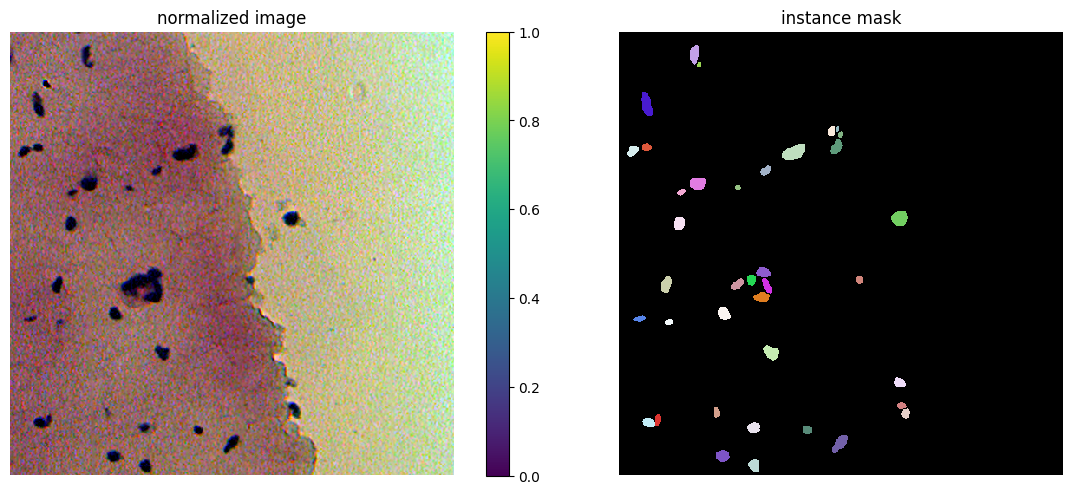

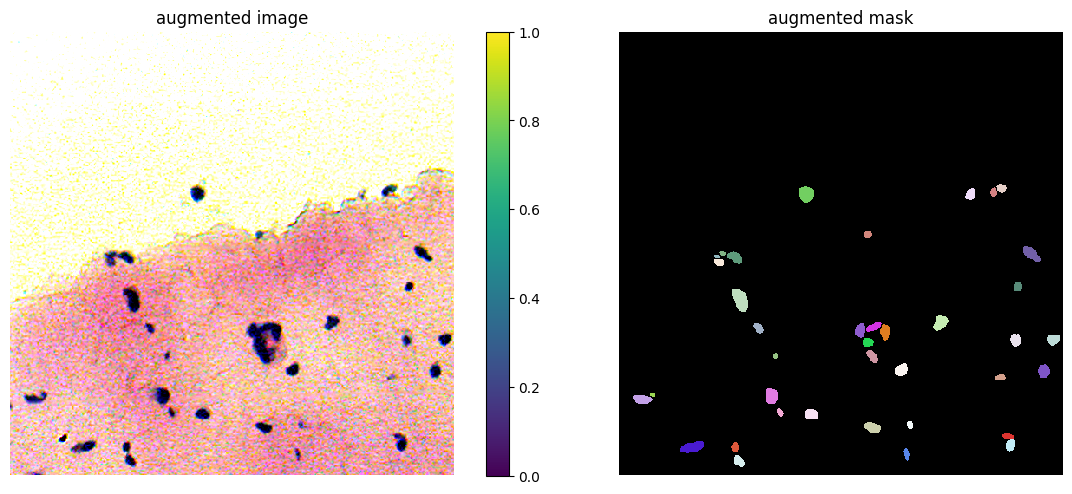

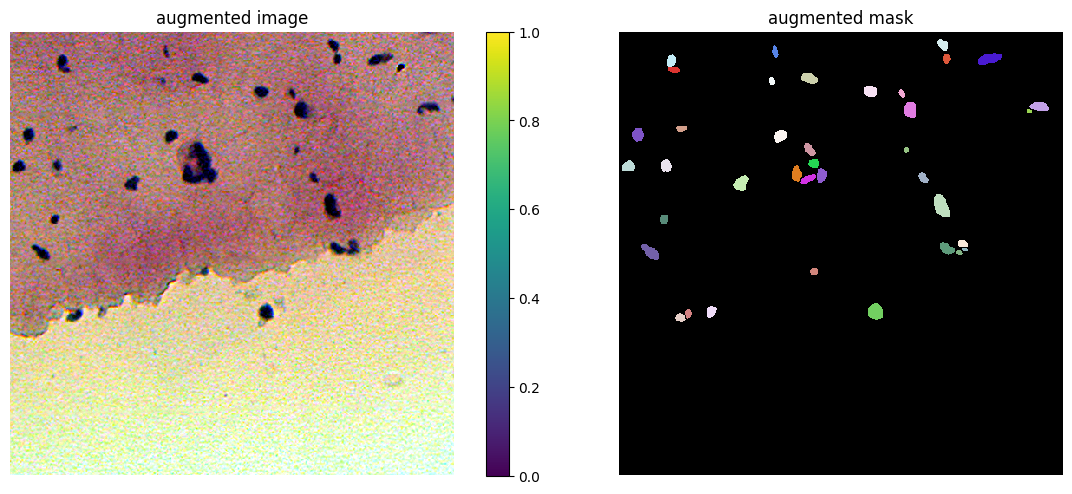

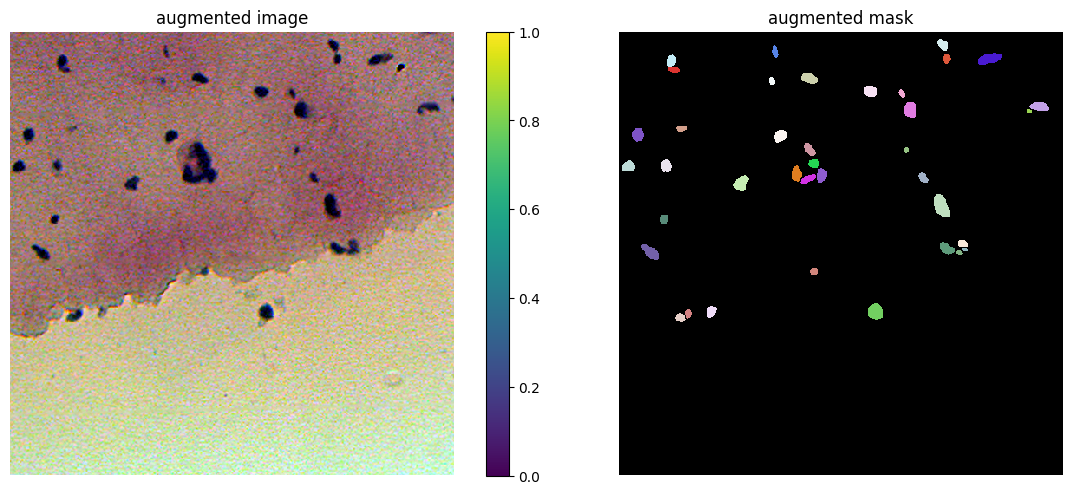

In [12]:
i = min(9, len(X) - 1)

img, lbl = X[i], Y[i]
assert img.ndim in (2, 3)
img_show = img if (img.ndim == 2 or img.shape[-1] == 3) else img[..., 0]
plot_img_label(img_show, lbl, img_title='normalized image', lbl_title='instance mask')

for _ in range(3):
    img_aug, lbl_aug = augmenter(img, lbl)
    img_aug_show = img_aug if (img_aug.ndim == 2 or img_aug.shape[-1] == 3) else img_aug[..., 0]
    plot_img_label(img_aug_show, lbl_aug, img_title='augmented image', lbl_title='augmented mask')

In [13]:
assert n_channel == 3, (
    f"Dataset ini memiliki n_channel={n_channel}. "
    "Pretrained model 2D_versatile_he mengharapkan citra RGB 3-channel."
)

# Muat model pretrained LANGSUNG dari folder lokal (offline), jangan pakai from_pretrained()
from pathlib import Path

PRETRAINED_LOCAL_PATH = Path('/data/work/python_2D_versatile_he')
assert PRETRAINED_LOCAL_PATH.exists(), (
    f"Folder model pretrained tidak ditemukan: {PRETRAINED_LOCAL_PATH}"
)
assert (PRETRAINED_LOCAL_PATH / 'config.json').exists(), (
    f"config.json tidak ditemukan di: {PRETRAINED_LOCAL_PATH}"
)

weight_candidates = sorted(PRETRAINED_LOCAL_PATH.glob('*.h5')) + sorted(PRETRAINED_LOCAL_PATH.glob('*.hdf5'))
assert len(weight_candidates) > 0, (
    f"Tidak ada file weights (*.h5 / *.hdf5) di: {PRETRAINED_LOCAL_PATH}"
)

pretrained_model = StarDist2D(
    None,
    name=PRETRAINED_LOCAL_PATH.name,
    basedir=str(PRETRAINED_LOCAL_PATH.parent),
)

print("Pretrained model loaded from local path:", PRETRAINED_LOCAL_PATH)
print("Resolved model directory:", pretrained_model.logdir)
print(pretrained_model.config)

2026-05-06 21:33:34.512408: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10248 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080 Ti, pci bus id: 0000:ca:00.0, compute capability: 8.6


Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.692478, nms_thresh=0.3.
Pretrained model loaded from local path: /data/work/python_2D_versatile_he
Resolved model directory: /data/work/python_2D_versatile_he
Config2D(n_dim=2, axes='YXC', n_channel_in=3, n_channel_out=33, train_checkpoint='weights_best.h5', train_checkpoint_last='weights_last.h5', train_checkpoint_epoch='weights_now.h5', n_rays=32, grid=(2, 2), backbone='unet', n_classes=None, unet_n_depth=3, unet_kernel_size=[3, 3], unet_n_filter_base=32, unet_n_conv_per_depth=2, unet_pool=[2, 2], unet_activation='relu', unet_last_activation='relu', unet_batch_norm=False, unet_dropout=0.0, unet_expansion=2, unet_prefix='', net_conv_after_unet=128, net_input_shape=[None, None, 3], net_mask_shape=[None, None, 1], train_shape_completion=False, train_completion_crop=32, train_patch_size=[512, 512], train_background_reg=0.0001, train_foreground_only=0.9, train_sam

In [14]:
conf = copy.deepcopy(pretrained_model.config)

pretrained_patch_size = tuple(int(v) for v in conf.train_patch_size)
all_fit_images = X_trn + X_val

safe_patch_size, patch_info = compute_safe_patch_size(
    all_fit_images,
    pretrained_patch_size=pretrained_patch_size,
    divisor=PATCH_SIZE_DIVISOR,
    force_patch_size=FORCE_PATCH_SIZE,
)

print("Patch size pretrained :", pretrained_patch_size)
print("Shape info dataset    :", patch_info)

# Siapkan data yang benar-benar dipakai saat fitting
if PATCH_SIZE_MODE == 'pad_to_pretrained':
    fit_patch_size = pretrained_patch_size
    X_trn_fit, Y_trn_fit = pad_dataset_to_shape(X_trn, Y_trn, fit_patch_size, img_mode=PAD_MODE)
    X_val_fit, Y_val_fit = pad_dataset_to_shape(X_val, Y_val, fit_patch_size, img_mode=PAD_MODE)
    print(f"PATCH_SIZE_MODE='pad_to_pretrained' -> gambar kecil dipad ke {fit_patch_size}")
else:
    fit_patch_size = safe_patch_size
    X_trn_fit, Y_trn_fit = X_trn, Y_trn
    X_val_fit, Y_val_fit = X_val, Y_val
    print(f"PATCH_SIZE_MODE='auto_smallest' -> train_patch_size aman = {fit_patch_size}")

# Penyesuaian parameter training untuk fine-tuning
conf.use_gpu = OPENCL_DATA_GENERATOR
conf.n_channel_in = n_channel
conf.train_learning_rate = LEARNING_RATE
conf.train_batch_size = BATCH_SIZE
conf.train_epochs = EPOCHS
conf.train_steps_per_epoch = STEPS_PER_EPOCH
conf.train_foreground_only = 0.9
conf.train_tensorboard = True
conf.train_reduce_lr = {'factor': 0.5, 'patience': 8, 'min_delta': 0}
conf.train_patch_size = tuple(int(v) for v in fit_patch_size)

print("Config fine-tuning:")
print(conf)


Patch size pretrained : (512, 512)
Shape info dataset    : {'min_shape': (256, 256), 'shape_counts': {(512, 512): 341, (256, 256): 2756, (500, 500): 37, (1516, 1509): 12, (1516, 1508): 7, (1516, 1512): 10, (1516, 1505): 2, (1516, 1511): 22, (1516, 1319): 2, (1516, 1514): 3, (1516, 1500): 6, (928, 1190): 1, (1146, 1318): 1, (1050, 1413): 1, (2175, 2019): 1, (1301, 2145): 1, (1113, 1286): 1, (877, 1245): 1, (836, 978): 1, (934, 1190): 1, (803, 1391): 1, (1113, 1462): 1, (1097, 984): 1, (1439, 1684): 1, (781, 1034): 1, (789, 1626): 1, (1007, 1076): 1, (1354, 1054): 1, (742, 992): 1, (1056, 1123): 1, (1612, 1884): 1, (782, 1140): 1, (660, 1446): 1, (1079, 1291): 1, (869, 1343): 1, (1056, 1465): 1, (753, 955): 1, (839, 1206): 1, (885, 1053): 1, (961, 1048): 1, (846, 1216): 1, (672, 1107): 1, (1235, 1253): 1, (1099, 1302): 1, (1168, 1614): 1, (874, 1017): 1, (1358, 1340): 1, (699, 970): 1, (2095, 1842): 1, (1057, 1137): 1, (911, 1035): 1, (867, 1028): 1, (981, 1311): 1, (1005, 1268): 1, (854

In [15]:
finetune_model = StarDist2D(conf, name=FINETUNE_MODEL_NAME, basedir=MODEL_BASEDIR)

# Salin weights dari pretrained ke model custom
_ = pretrained_model.keras_model
_ = finetune_model.keras_model
finetune_model.keras_model.set_weights(pretrained_model.keras_model.get_weights())

# Opsional: mulai dari threshold pretrained sebelum nanti di-optimize ulang
try:
    finetune_model.thresholds = copy.deepcopy(pretrained_model.thresholds)
    print("Threshold pretrained berhasil disalin:", finetune_model.thresholds)
except Exception as e:
    print("Threshold pretrained tidak bisa disalin, lanjut saja. Detail:", e)

print("Bobot pretrained berhasil disalin ke model fine-tuning.")

Using default values: prob_thresh=0.5, nms_thresh=0.4.
Threshold pretrained tidak bisa disalin, lanjut saja. Detail: 'Thresholds' object has no attribute 'keys'
Bobot pretrained berhasil disalin ke model fine-tuning.


base_model.py (203): output path for model already exists, files may be overwritten: /data/work/FineTuning/Models/stardist_model_C_3000


In [16]:
median_size = calculate_extents(list(Y), np.median)
fov = np.array(finetune_model._axes_tile_overlap('YX'))
print(f"median object size:      {median_size}")
print(f"network field of view :  {fov}")

if any(median_size > fov):
    print("WARNING: median object size larger than field of view of the neural network.")
else:
    print("OK: median object size masih lebih kecil dari field of view.")

I0000 00:00:1778074431.322278  873379 service.cc:145] XLA service 0x7f17ac009b40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778074431.322358  873379 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3080 Ti, Compute Capability 8.6
2026-05-06 21:33:51.368533: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-06 21:33:51.455960: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1778074432.824279  873379 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


median object size:      [23. 23.]
network field of view :  [78 78]
OK: median object size masih lebih kecil dari field of view.


In [17]:
history = finetune_model.train(
    X_trn_fit,
    Y_trn_fit,
    validation_data=(X_val_fit, Y_val_fit),
    augmenter=augmenter,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH
)

Epoch 1/150
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 147ms/step - dist_dist_iou_metric: 0.6530 - dist_loss: 2.6641 - dist_relevant_mae: 2.6634 - dist_relevant_mse: 22.7277 - loss: 0.4090 - prob_kld: 0.0491 - prob_loss: 0.1426 - val_dist_dist_iou_metric: 0.6392 - val_dist_loss: 2.6970 - val_dist_relevant_mae: 2.6963 - val_dist_relevant_mse: 18.3436 - val_loss: 0.4198 - val_prob_kld: 0.0529 - val_prob_loss: 0.1501 - learning_rate: 1.0000e-04
Epoch 2/150
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - dist_dist_iou_metric: 0.6542 - dist_loss: 2.6665 - dist_relevant_mae: 2.6658 - dist_relevant_mse: 21.3761 - loss: 0.4054 - prob_kld: 0.0471 - prob_loss: 0.1387 - val_dist_dist_iou_metric: 0.6371 - val_dist_loss: 2.5552 - val_dist_relevant_mae: 2.5545 - val_dist_relevant_mse: 16.3273 - val_loss: 0.4048 - val_prob_kld: 0.0521 - val_prob_loss: 0.1493 - learning_rate: 1.0000e-04
Epoch 3/150
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - dist_dist_iou_metric: 0.6449 - dist_loss: 2.6279 - dist_relevant_mae: 2.62

In [18]:
history_df = pd.DataFrame(history.history)
history_df.insert(0, 'epoch', np.arange(1, len(history_df) + 1))

model_dir = os.path.join(MODEL_BASEDIR, FINETUNE_MODEL_NAME)
Path(model_dir).mkdir(parents=True, exist_ok=True)

history_csv = os.path.join(model_dir, 'history_finetune.csv')
history_df.to_csv(history_csv, index=False)

best_val_loss_epoch = int(history_df.loc[history_df['val_loss'].idxmin(), 'epoch'])
best_val_iou_epoch = int(history_df.loc[history_df['val_dist_dist_iou_metric'].idxmax(), 'epoch'])

print("History saved to:", history_csv)
print("Best val_loss epoch:", best_val_loss_epoch)
print("Best val_dist_dist_iou_metric epoch:", best_val_iou_epoch)

display(history_df.tail())

History saved to: /data/work/FineTuning/Models/stardist_model_C_3000/history_finetune.csv
Best val_loss epoch: 43
Best val_dist_dist_iou_metric epoch: 82


,epoch,dist_dist_iou_metric,dist_loss,dist_relevant_mae,dist_relevant_mse,loss,prob_kld,prob_loss,val_dist_dist_iou_metric,val_dist_loss,val_dist_relevant_mae,val_dist_relevant_mse,val_loss,val_prob_kld,val_prob_loss,learning_rate
145,146,0.690459,2.271212,2.270511,15.759568,0.364626,0.042957,0.137504,0.685705,2.253383,2.252695,14.009174,0.367601,0.045075,0.142262,1.220703e-08
146,147,0.690389,2.332538,2.331836,19.643990,0.362632,0.041862,0.129378,0.685706,2.253118,2.252430,14.005708,0.367573,0.045074,0.142261,1.220703e-08
147,148,0.697007,2.219704,2.219008,15.240015,0.356495,0.041666,0.134525,0.685708,2.253223,2.252535,14.007115,0.367584,0.045074,0.142261,6.103515e-09
148,149,0.701944,2.188102,2.187402,14.857313,0.348899,0.039983,0.130089,0.685708,2.253155,2.252467,14.006036,0.367577,0.045074,0.142261,6.103515e-09
149,150,0.693223,2.230751,2.230057,15.568874,0.364909,0.044382,0.141834,0.685707,2.253130,2.252441,14.005512,0.367574,0.045074,0.142261,6.103515e-09


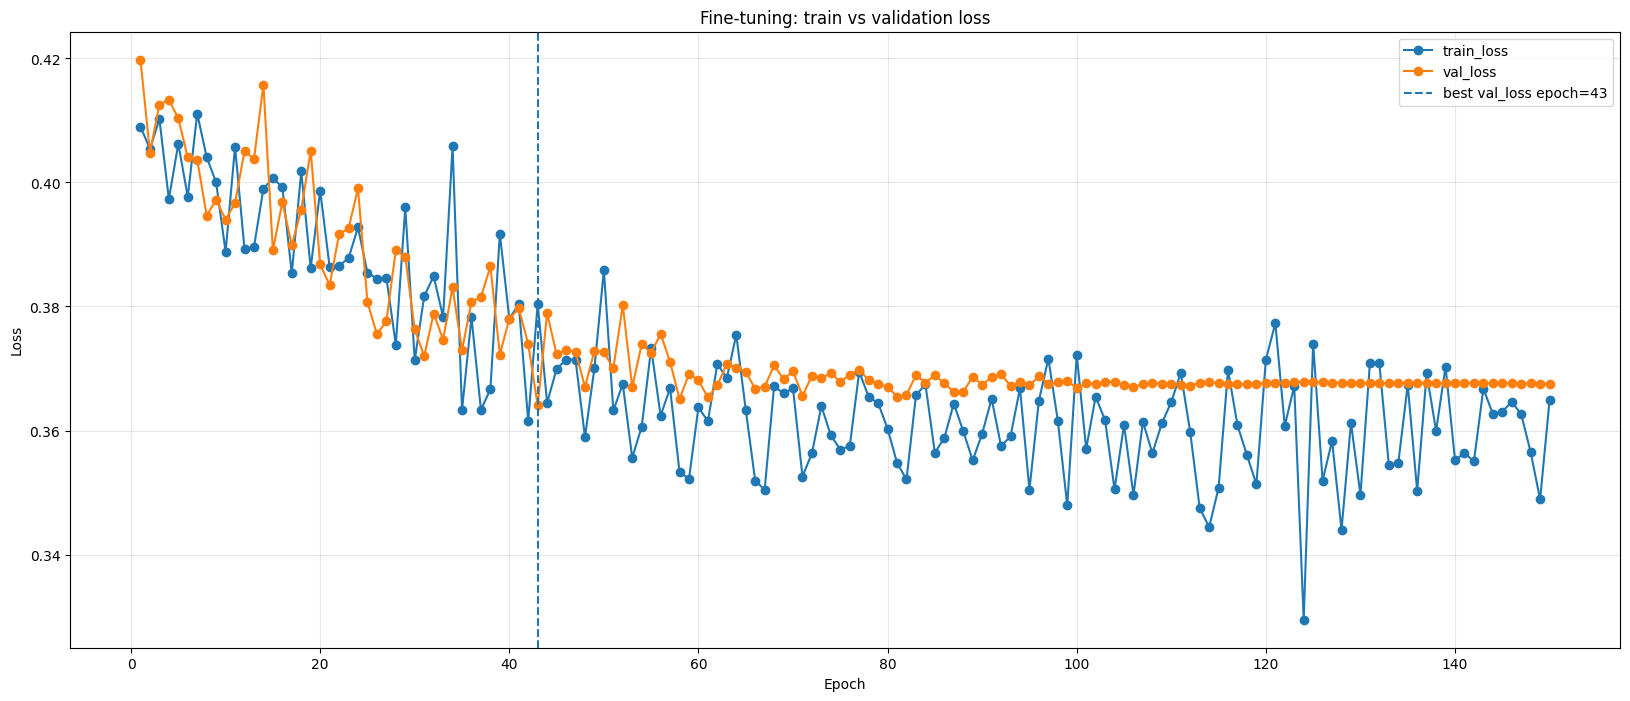

In [23]:
plt.figure(figsize=(20, 8))
plt.plot(history_df['epoch'], history_df['loss'], marker='o', label='train_loss')
plt.plot(history_df['epoch'], history_df['val_loss'], marker='o', label='val_loss')
plt.axvline(best_val_loss_epoch, linestyle='--', label=f'best val_loss epoch={best_val_loss_epoch}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fine-tuning: train vs validation loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

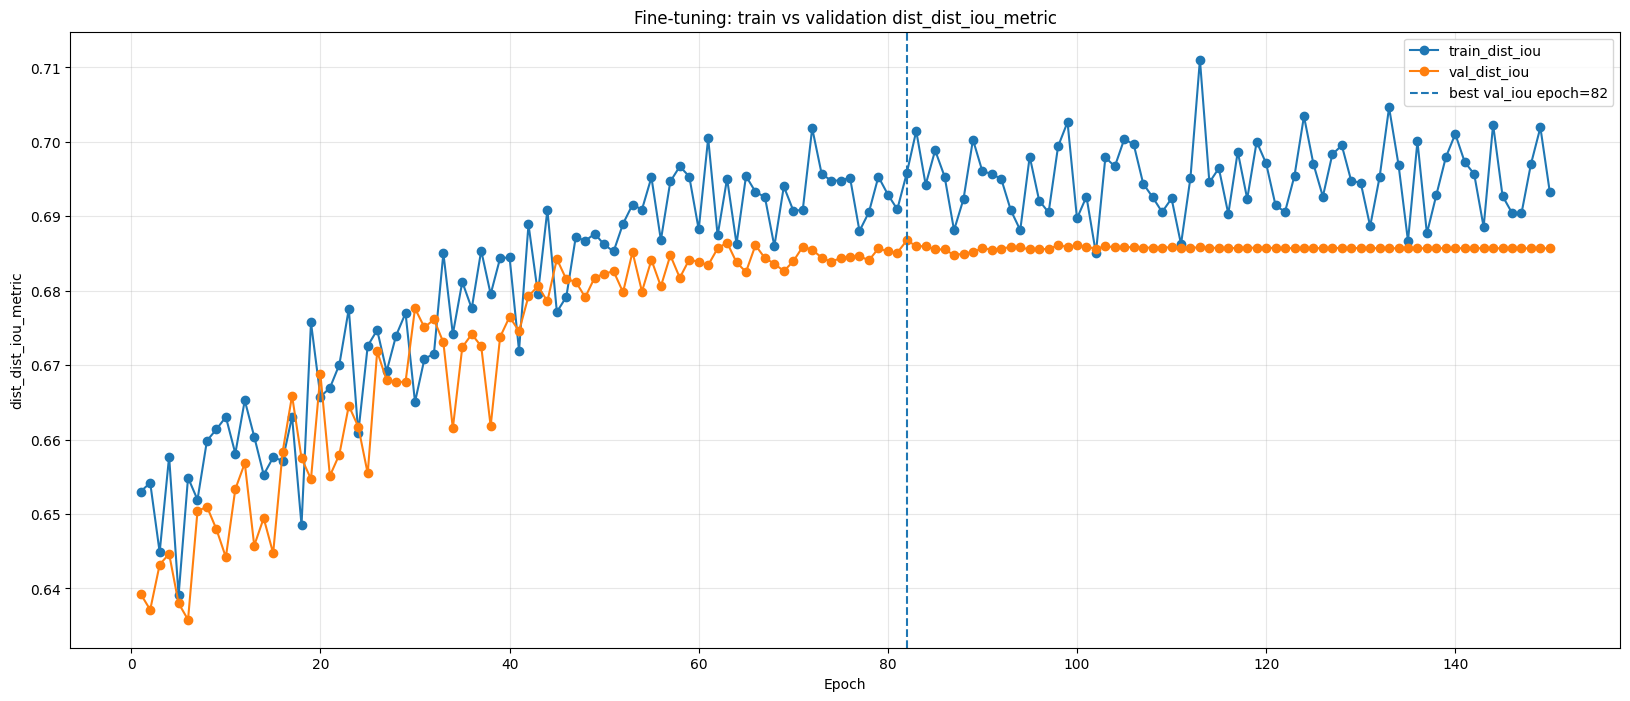

In [24]:
plt.figure(figsize=(20, 8))
plt.plot(history_df['epoch'], history_df['dist_dist_iou_metric'], marker='o', label='train_dist_iou')
plt.plot(history_df['epoch'], history_df['val_dist_dist_iou_metric'], marker='o', label='val_dist_iou')
plt.axvline(best_val_iou_epoch, linestyle='--', label=f'best val_iou epoch={best_val_iou_epoch}')
plt.xlabel('Epoch')
plt.ylabel('dist_dist_iou_metric')
plt.title('Fine-tuning: train vs validation dist_dist_iou_metric')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

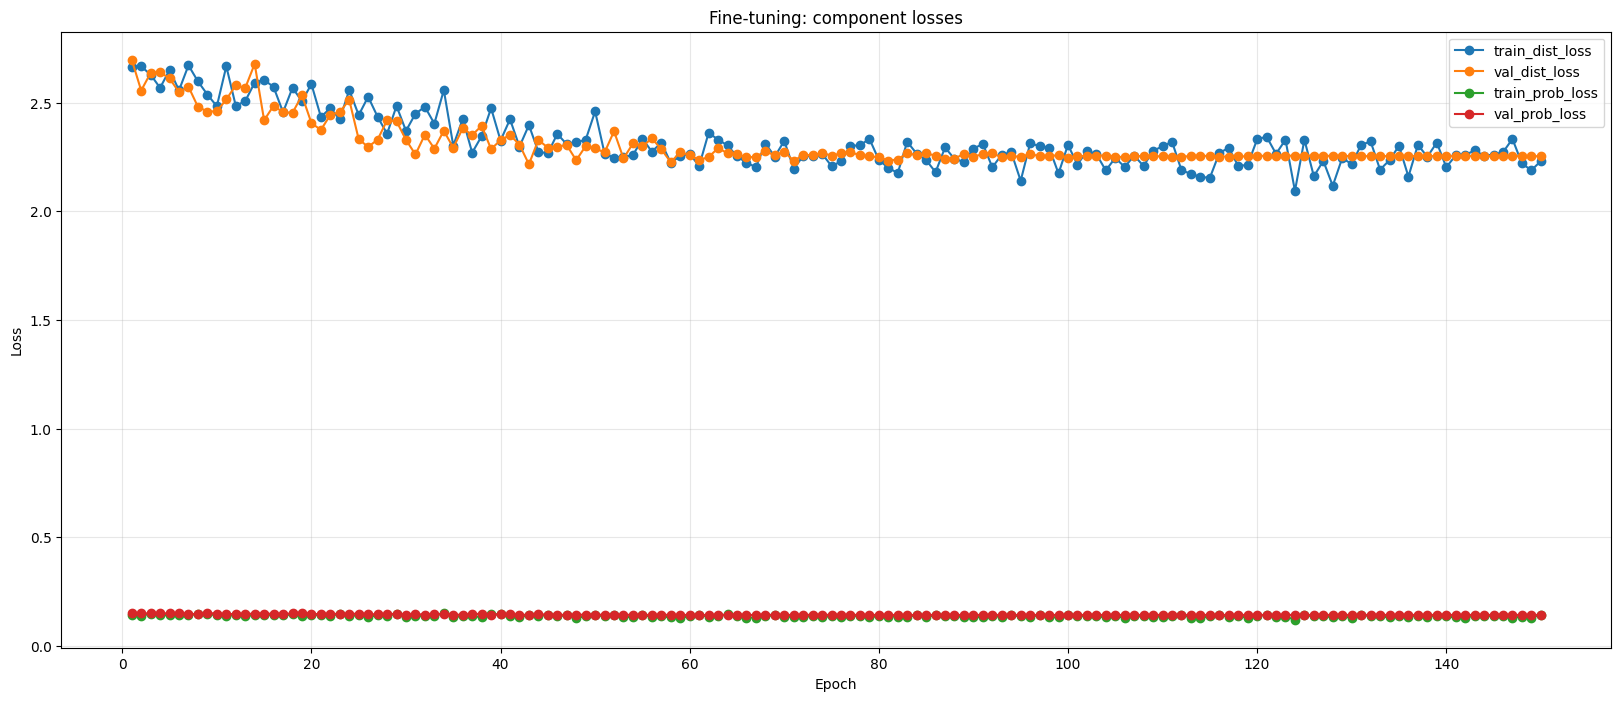

In [25]:
plt.figure(figsize=(20, 8))
plt.plot(history_df['epoch'], history_df['dist_loss'], marker='o', label='train_dist_loss')
plt.plot(history_df['epoch'], history_df['val_dist_loss'], marker='o', label='val_dist_loss')
plt.plot(history_df['epoch'], history_df['prob_loss'], marker='o', label='train_prob_loss')
plt.plot(history_df['epoch'], history_df['val_prob_loss'], marker='o', label='val_prob_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fine-tuning: component losses')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [27]:
finetune_model.optimize_thresholds(X_val, Y_val)

NMS threshold = 0.3:  35%|███▌      | 7/20 [24:37<41:36, 192.01s/it, 0.474 -> 0.452]  IOStream.flush timed out
IOStream.flush timed out
NMS threshold = 0.3:  55%|█████▌    | 11/20 [53:15<49:27, 329.72s/it, 0.474 -> 0.452]IOStream.flush timed out
IOStream.flush timed out
NMS threshold = 0.4:  55%|█████▌    | 11/20 [54:58<51:10, 341.11s/it, 0.474 -> 0.453]IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
NMS threshold = 0.5:  80%|████████  | 16/20 [1:42:20<25:35, 383.78s/it, 0.475 -> 0.452]


Using optimized values: prob_thresh=0.473535, nms_thresh=0.4.
Saving to 'thresholds.json'.


{'prob': 0.473535418510437, 'nms': 0.4}

In [28]:
best_model = StarDist2D(None, name=FINETUNE_MODEL_NAME, basedir=MODEL_BASEDIR)

Y_val_pred = [
    best_model.predict_instances(x, n_tiles=best_model._guess_n_tiles(x), show_tile_progress=False)[0]
    for x in tqdm(X_val, desc='Predict validation')
]

print("Jumlah prediksi validation:", len(Y_val_pred))

Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.473535, nms_thresh=0.4.


Predict validation: 100%|██████████| 501/501 [17:24<00:00,  2.08s/it] 

Jumlah prediksi validation: 501


In [29]:
taus = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
stats = [matching_dataset(Y_val, Y_val_pred, thresh=t, show_progress=False) for t in tqdm(taus, desc='Instance metrics')]

inst_metrics_df = pd.DataFrame([s._asdict() for s in stats])
inst_metrics_df.insert(0, 'iou_thresh', taus)

inst_metrics_csv = os.path.join(model_dir, 'instance_metrics_validation_across_thresholds.csv')
inst_metrics_df.to_csv(inst_metrics_csv, index=False)

print("Instance metrics saved to:", inst_metrics_csv)
display(inst_metrics_df)

Instance metrics: 100%|██████████| 10/10 [02:29<00:00, 14.97s/it]

Instance metrics saved to: /data/work/FineTuning/Models/stardist_model_C_3000/instance_metrics_validation_across_thresholds.csv


,iou_thresh,criterion,thresh,fp,tp,fn,precision,recall,accuracy,f1,n_true,n_pred,mean_true_score,mean_matched_score,panoptic_quality,by_image
0,0.0,iou,0.0,1384,83108,14997,0.983620,0.847133,0.835349,0.910289,98105,84492,0.489858,0.578253,0.526377,False
1,0.1,iou,0.1,10397,74095,24010,0.876947,0.755262,0.682891,0.811569,98105,84492,0.489618,0.648276,0.526120,False
2,0.2,iou,0.2,10975,73517,24588,0.870106,0.749371,0.673973,0.805238,98105,84492,0.488763,0.652231,0.525201,False
3,0.3,iou,0.3,12541,71951,26154,0.851572,0.733408,0.650281,0.788085,98105,84492,0.484682,0.660863,0.520816,False
4,0.4,iou,0.4,16797,67695,30410,0.801200,0.690026,0.589154,0.741469,98105,84492,0.469248,0.680044,0.504232,False
5,0.5,iou,0.5,24174,60318,37787,0.713890,0.614831,0.493282,0.660668,98105,84492,0.435275,0.707958,0.467725,False
6,0.6,iou,0.6,35351,49141,48964,0.581605,0.500902,0.368219,0.538245,98105,84492,0.372346,0.743351,0.400105,False
7,0.7,iou,0.7,51765,32727,65378,0.387338,0.333592,0.218369,0.358462,98105,84492,0.263213,0.789028,0.282836,False
8,0.8,iou,0.8,71189,13303,84802,0.157447,0.135600,0.078579,0.145709,98105,84492,0.114885,0.847239,0.123450,False
9,0.9,iou,0.9,83339,1153,96952,0.013646,0.011753,0.006355,0.012629,98105,84492,0.010781,0.917298,0.011584,False


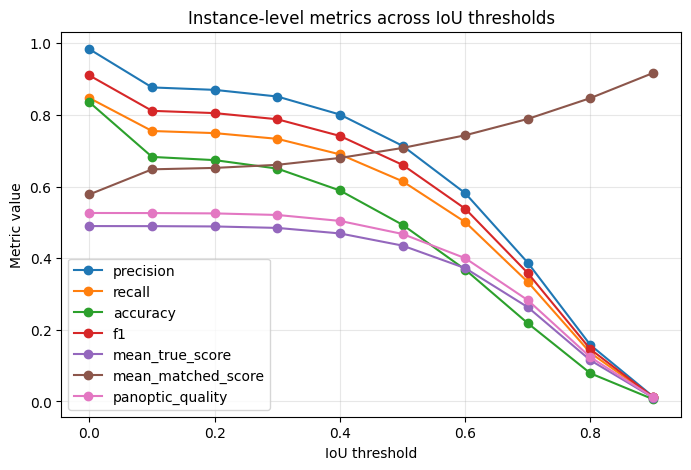

In [30]:
plt.figure(figsize=(8, 5))
for metric_name in ['precision', 'recall', 'accuracy', 'f1', 'mean_true_score', 'mean_matched_score', 'panoptic_quality']:
    plt.plot(inst_metrics_df['iou_thresh'], inst_metrics_df[metric_name], marker='o', label=metric_name)
plt.xlabel('IoU threshold')
plt.ylabel('Metric value')
plt.title('Instance-level metrics across IoU thresholds')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

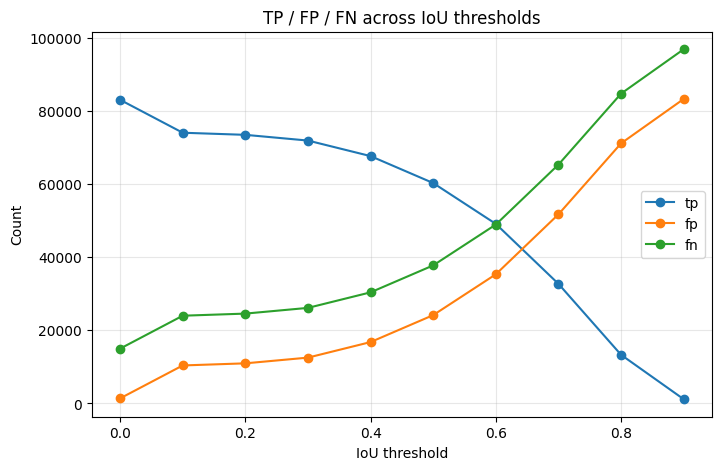

In [31]:
plt.figure(figsize=(8, 5))
for metric_name in ['tp', 'fp', 'fn']:
    plt.plot(inst_metrics_df['iou_thresh'], inst_metrics_df[metric_name], marker='o', label=metric_name)
plt.xlabel('IoU threshold')
plt.ylabel('Count')
plt.title('TP / FP / FN across IoU thresholds')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [32]:
per_image_inst_records = []
for idx, (x_path, y_true, y_pred) in enumerate(zip(X_val_files, Y_val, Y_val_pred)):
    m = matching(y_true, y_pred, thresh=0.5)
    rec = m._asdict()
    rec['image_idx'] = idx
    rec['image_name'] = os.path.basename(x_path)
    per_image_inst_records.append(rec)

per_image_inst_df = pd.DataFrame(per_image_inst_records)
per_image_inst_csv = os.path.join(model_dir, 'instance_metrics_validation_per_image_tau05.csv')
per_image_inst_df.to_csv(per_image_inst_csv, index=False)

print("Per-image instance metrics saved to:", per_image_inst_csv)
display(per_image_inst_df.head())

summary_inst_tau05 = per_image_inst_df[['precision', 'recall', 'accuracy', 'f1', 'panoptic_quality', 'mean_true_score', 'mean_matched_score']].agg(['mean', 'std'])
display(summary_inst_tau05)

Per-image instance metrics saved to: /data/work/FineTuning/Models/stardist_model_C_3000/instance_metrics_validation_per_image_tau05.csv


,criterion,thresh,fp,tp,fn,precision,recall,accuracy,f1,n_true,n_pred,mean_true_score,mean_matched_score,panoptic_quality,image_idx,image_name
0,iou,0.5,88,326,166,0.787440,0.662602,0.562069,0.719647,492,414,0.476120,0.718561,0.517110,0,CellBinDB_HE__HH799998676GI_X7-x7139_y387_w512...
1,iou,0.5,77,552,216,0.877583,0.718750,0.653254,0.790265,768,629,0.526760,0.732884,0.579172,1,CellBinDB_HE__HH799998676GI_X7-x7920_y13013_w5...
2,iou,0.5,13,50,14,0.793651,0.781250,0.649351,0.787402,64,63,0.613405,0.785158,0.618235,2,CellBinDB_HE__HH799999356_M1-x2560_y13312_w512...
3,iou,0.5,9,50,11,0.847458,0.819672,0.714286,0.833333,61,59,0.656906,0.801425,0.667855,3,CellBinDB_HE__HH799999356_M1-x6656_y14848_w512...
4,iou,0.5,6,61,11,0.910448,0.847222,0.782051,0.877698,72,67,0.691347,0.816016,0.716215,4,CellBinDB_HE__HH799999356_N5-x6144_y8192_w512_...


,precision,recall,accuracy,f1,panoptic_quality,mean_true_score,mean_matched_score
mean,0.761480,0.714541,0.593335,0.723852,0.559251,0.552636,0.746585
std,0.206846,0.186023,0.185697,0.184053,0.153675,0.155178,0.138901


In [33]:
binary_records = []
for idx, (x_path, y_true, y_pred) in enumerate(zip(X_val_files, Y_val, Y_val_pred)):
    rec = binary_metrics(y_true, y_pred)
    rec['image_idx'] = idx
    rec['image_name'] = os.path.basename(x_path)
    binary_records.append(rec)

binary_df = pd.DataFrame(binary_records)
binary_csv = os.path.join(model_dir, 'binary_metrics_validation_per_image.csv')
binary_df.to_csv(binary_csv, index=False)

print("Binary metrics saved to:", binary_csv)
display(binary_df.head())

binary_summary = binary_df[['iou', 'precision', 'recall', 'f1', 'dice', 'accuracy']].agg(['mean', 'std'])
display(binary_summary)

Binary metrics saved to: /data/work/FineTuning/Models/stardist_model_C_3000/binary_metrics_validation_per_image.csv


,tp_px,fp_px,fn_px,tn_px,iou,precision,recall,f1,dice,accuracy,image_idx,image_name
0,58723,14767,15795,172859,0.657703,0.799061,0.788038,0.793511,0.793511,0.883415,0,CellBinDB_HE__HH799998676GI_X7-x7139_y387_w512...
1,91289,18647,21233,130975,0.695965,0.830383,0.811299,0.820730,0.820730,0.847870,1,CellBinDB_HE__HH799998676GI_X7-x7920_y13013_w5...
2,7454,2584,1000,251106,0.675303,0.742578,0.881713,0.806186,0.806186,0.986328,2,CellBinDB_HE__HH799999356_M1-x2560_y13312_w512...
3,7655,1974,776,251739,0.735704,0.794994,0.907959,0.847730,0.847730,0.989510,3,CellBinDB_HE__HH799999356_M1-x6656_y14848_w512...
4,11360,1312,2376,247096,0.754918,0.896465,0.827024,0.860345,0.860345,0.985931,4,CellBinDB_HE__HH799999356_N5-x6144_y8192_w512_...


,iou,precision,recall,f1,dice,accuracy
mean,0.630530,0.786399,0.750798,0.758660,0.758660,0.928500
std,0.153834,0.179899,0.152985,0.159692,0.159692,0.047116


Worst sample : PanNuke__1632-img.TIF IoU = 0.0
Median sample: PanNuke__0080-img.TIF IoU = 0.6692607003853849
Best sample  : PanNuke__1228-img.TIF IoU = 0.8673532440773765


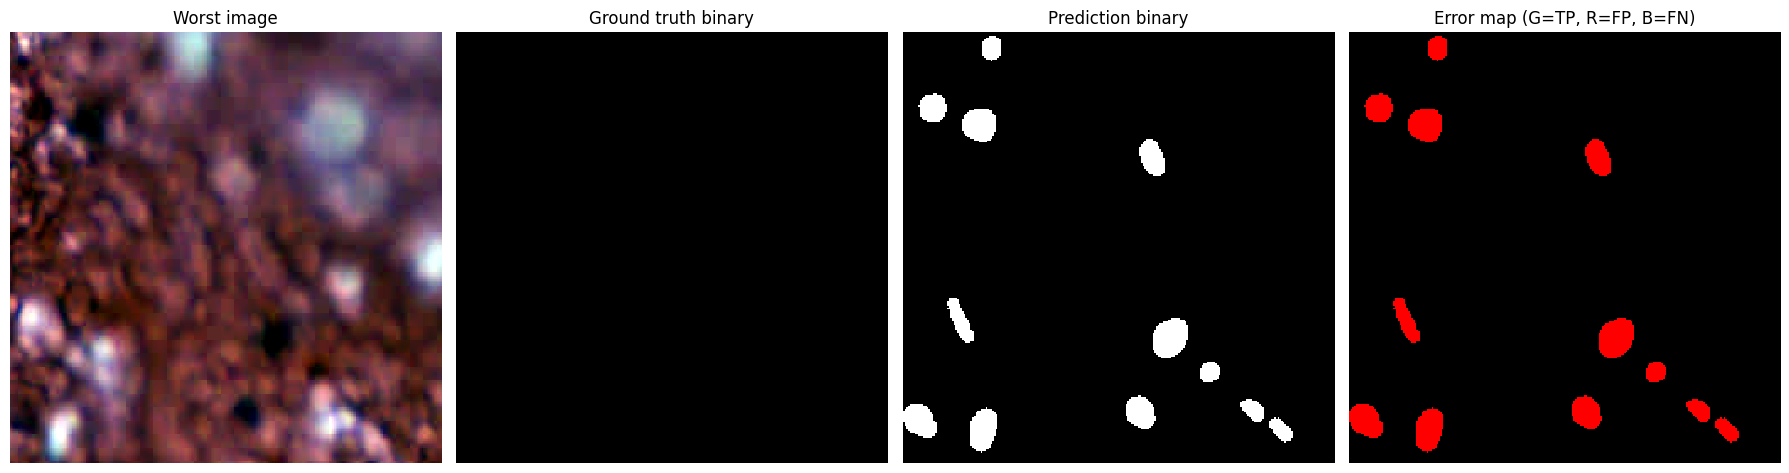

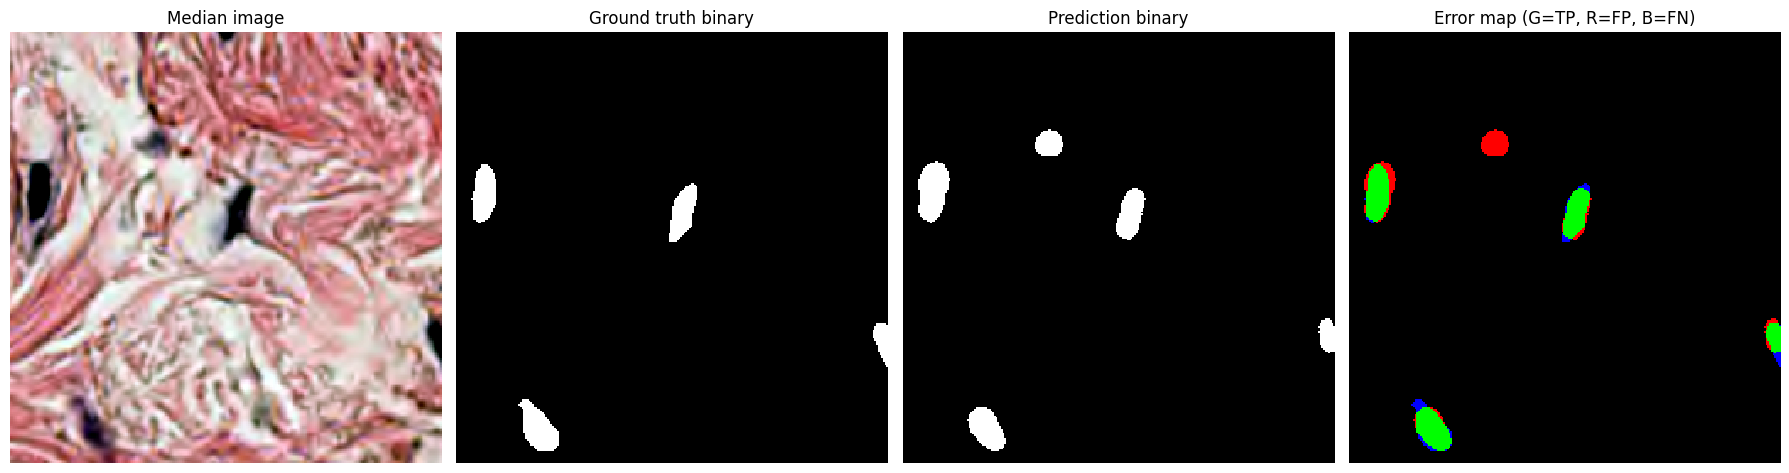

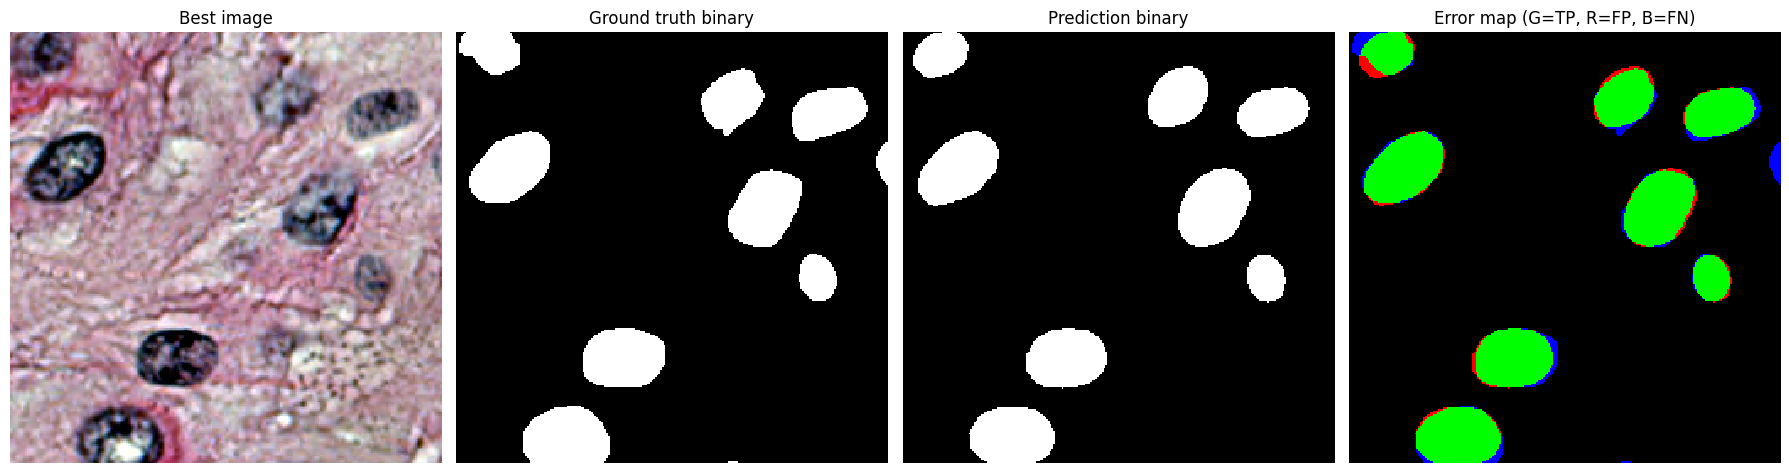

In [34]:
binary_sorted = binary_df.sort_values('iou').reset_index(drop=True)

worst_idx = int(binary_sorted.iloc[0]['image_idx'])
median_idx = int(binary_sorted.iloc[len(binary_sorted)//2]['image_idx'])
best_idx = int(binary_sorted.iloc[-1]['image_idx'])

print("Worst sample :", binary_sorted.iloc[0]['image_name'], 'IoU =', binary_sorted.iloc[0]['iou'])
print("Median sample:", binary_sorted.iloc[len(binary_sorted)//2]['image_name'], 'IoU =', binary_sorted.iloc[len(binary_sorted)//2]['iou'])
print("Best sample  :", binary_sorted.iloc[-1]['image_name'], 'IoU =', binary_sorted.iloc[-1]['iou'])

show_prediction_triplet(X_val[worst_idx],  Y_val[worst_idx],  Y_val_pred[worst_idx],  title_prefix='Worst')
show_prediction_triplet(X_val[median_idx], Y_val[median_idx], Y_val_pred[median_idx], title_prefix='Median')
show_prediction_triplet(X_val[best_idx],   Y_val[best_idx],   Y_val_pred[best_idx],   title_prefix='Best')

In [35]:
if EXPORT_VAL_PREDICTIONS:
    for x_path, y_pred in zip(X_val_files, Y_val_pred):
        stem = Path(x_path).stem
        out_inst = os.path.join(PRED_EXPORT_DIR, f'{stem}_pred_instance.tif')
        out_bin = os.path.join(PRED_EXPORT_DIR, f'{stem}_pred_binary.tif')

        imwrite(out_inst, y_pred.astype(np.uint16))
        imwrite(out_bin, instance_to_binary(y_pred).astype(np.uint8))

    print("Semua prediksi validation berhasil disimpan ke:")
    print(PRED_EXPORT_DIR)
else:
    print("Export prediksi dimatikan.")

Semua prediksi validation berhasil disimpan ke:
/data/work/FineTuning/Models/stardist_model_C_3000/val_predictions
